In [10]:
# ==================== IMPORTS & CLEAN DATA ====================
%run CleanData.ipynb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

from imblearn.over_sampling import RandomOverSampler

In [11]:
# ==================== AUTOENCODER ====================
input_dim = X_train.shape[1]
encoding_dim = 64

input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)

decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

autoencoder.compile(optimizer=Adam(1e-3), loss='mse')
autoencoder.fit(
    X_train, X_train,
    epochs=10, batch_size=32,
    validation_data=(X_test, X_test),
    verbose=1
)

Epoch 1/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0127 - val_loss: 0.0015
Epoch 2/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0013 - val_loss: 9.7740e-04
Epoch 3/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 9.4047e-04 - val_loss: 8.1420e-04
Epoch 4/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 7.8822e-04 - val_loss: 6.9435e-04
Epoch 5/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 7.0299e-04 - val_loss: 6.4939e-04
Epoch 6/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 6.4320e-04 - val_loss: 6.3502e-04
Epoch 7/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 6.1083e-04 - val_loss: 5.6893e-04
Epoch 8/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 5.7902e-04 - val_loss: 5.9046e-04
Epoch 9/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 5.4701e-04 - val_loss: 5.2578e-04
Epoch 10/10
3100/3100 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 5.2977e-04 - val_loss: 5.3300e-04


In [12]:
# ==================== FEATURE EXTRACTION ====================
X_train_encoded = encoder.predict(X_train)
X_test_encoded  = encoder.predict(X_test)

3100/3100 ━━━━━━━━━━━━━━━━━━━━ 2s 614us/step
776/776 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step


In [13]:
# ==================== OVERSAMPLING ====================
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train_encoded, y_train)

c:\Users\plui0\anaconda3\envs\tfcpu\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\plui0\anaconda3\envs\tfcpu\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
c:\Users\plui0\anaconda3\envs\tfcpu\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [14]:
# ==================== RANDOM FOREST ====================
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_resampled, y_resampled)
y_pred = rf.predict(X_test_encoded)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     18952
           1       0.97      0.60      0.74       556
           2       0.98      0.86      0.91      1448
           3       0.81      0.62      0.71       162
           4       1.00      0.92      0.96      1608
           5       0.97      0.70      0.81      2077

    accuracy                           0.95     24803
   macro avg       0.94      0.78      0.85     24803
weighted avg       0.95      0.95      0.94     24803



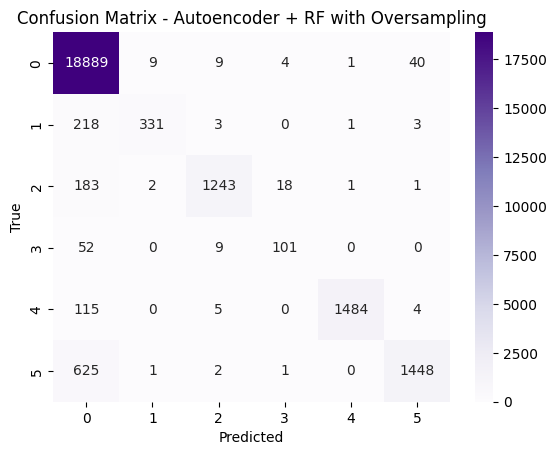

In [15]:
# ==================== EVALUATION ====================
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Autoencoder + RF with Oversampling")
plt.show()


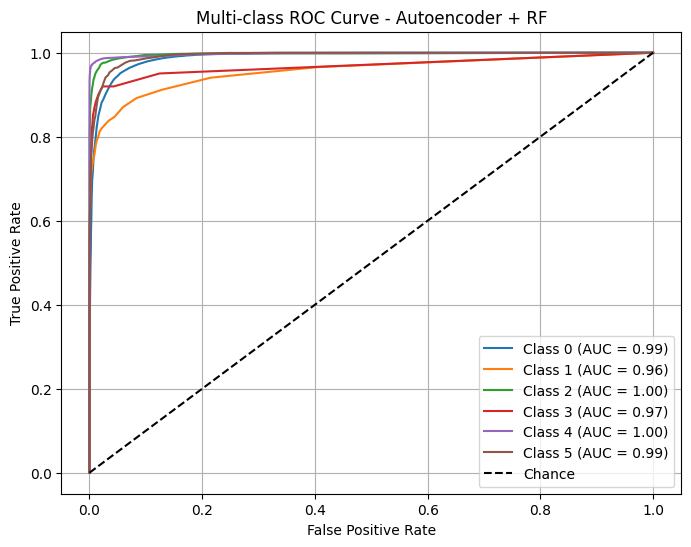

In [16]:
# ==================== ROC & AUC ====================
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
y_prob     = rf.predict_proba(X_test_encoded)
n_classes  = y_test_bin.shape[1]

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve - Autoencoder + RF')
plt.legend(loc='lower right')
plt.grid()
plt.show()
